# HW2  Regression Fun Time!

Please run the cell below to import libraries needed for this HW. Please use the autograd numpy, otherwise you will have issues.

In [1]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
%matplotlib inline


Q1) **[10 points]**

Implement the linear regression model discussed in class below. The function (called model) takes in an array of data points, x , and an array of weights, w, and returns a vector y_predicted containing the linear combination for each of the data points. This is the linear model we have discussed in class. You can assume each data point in x only has one feature.  The length of the vector being returned should be the same as x.


In [2]:
def model(x, w):
    """
    Linear regression model: y = w0 + w1*x
    """
    # w[0] is the intercept, w[1] is the slope
    y_predicted = w[0] + w[1] * x
    return y_predicted

Q2) **[10 ponts]**

Implement the least squares function discussed in class below. The function should take in an array of weights, w, an array of x's and an array of ys. It should use the model function implemented above and return a float indicating the total cost.

In [3]:
def least_squares(w, x, y):
    """
    Least squares cost function for linear regression
    """
    # Get predictions using the model
    y_pred = model(x, w)
    
    # Calculate squared errors
    squared_errors = (y_pred - y) ** 2
    
    # Sum all squared errors
    cost = np.sum(squared_errors)
    
    return cost

Q3) **[5 point]**

This one is a freebie from HW1. Copy and paste your gradient descent function here. Specifically, the one that takes in the cost function as input and return the weight and cost history. We will be using a fixed alpha for this HW. The only difference is that this function should now also take in as input an array of x and ys, corresponding to our data. The w,x, and y are given as inputs to the cost funtion and its gradient.

In [4]:
def gradient_descent(g, alpha, max_its, w, x, y):
    """
    Gradient descent optimization algorithm
    """
    # Initialize gradient function using autograd
    gradient = grad(g)
    
    # Initialize history arrays
    weight_history = [w]
    cost_history = [g(w, x, y)]
    
    # Perform gradient descent
    for i in range(max_its):
        # Compute gradient
        grad_val = gradient(w, x, y)
        
        # Update weights
        w = w - alpha * grad_val
        
        # Store history
        weight_history.append(w)
        cost_history.append(g(w, x, y))
    
    return np.array(weight_history), np.array(cost_history)

Q4) **[1 points]**  
Run the code below to import a dataset. Then, plot a scatter plot of the data (x vs y).

In [6]:
# import the dataset
## Carefully check the path
csvname = '/Users/user_1/mlpro/Regression/HW2/kleibers_law_data.csv'
data = np.loadtxt(csvname,delimiter=',')
x = np.log(data[:-1,:])
y = np.log(data[-1:,:])


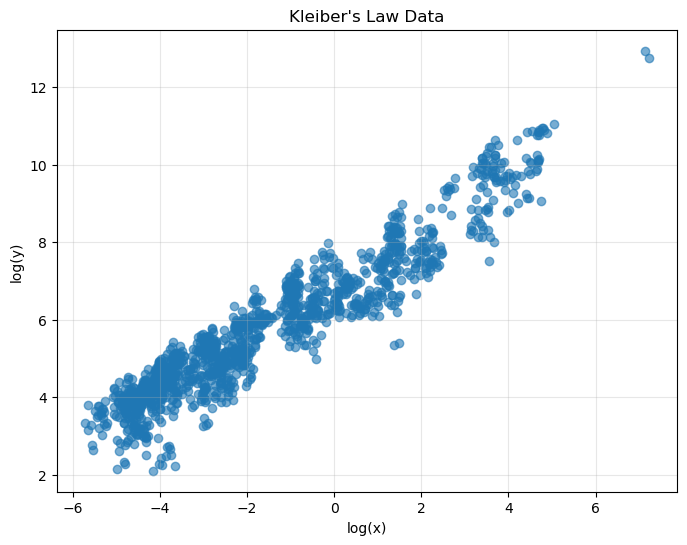

In [7]:
# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.title('Kleiber\'s Law Data')
plt.grid(True, alpha=0.3)
plt.show()

Q5) **[10 points]**

[Part 1] Use your gradient descent function to learn a linear regression model for the x and y above using the following parameters and plot the cost_history over the 1000 iterations

g = least_squares function you implemented

w = [w_0, w_1]  , where w_0 and w_1 are random numbers between -0.1 and 0.1

max_its=1000

alpha=0.01

/var/folders/4n/06mch31d0cbcd74b39xf1v300000gp/T/ipykernel_24355/141668621.py:9: RuntimeWarning: overflow encountered in square
  squared_errors = (y_pred - y) ** 2
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/anaconda3/lib/python3.12/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in power
  return f_raw(*args, **kwargs)
/var/folders/4n/06mch31d0cbcd74b39xf1v300000gp/T/ipykernel_24355/2832081063.py:6: RuntimeWarning: invalid value encountered in multiply
  y_predicted = w[0] + w[1] * x
/var/folders/4n/06mch31d0cbcd74b39xf1v300000gp/T/ipykernel_24355/2832081063.py:6: RuntimeWarning: invalid value encountered in add
  y_predicted = w[0] + w[1] * x
/opt/anaconda3/lib/python3.12/site-packages/autograd/tracer.py:54: RuntimeWarning: invalid value encountered in multiply
  return f_raw(*args, **kwargs)
/opt/anaconda3/lib/python3

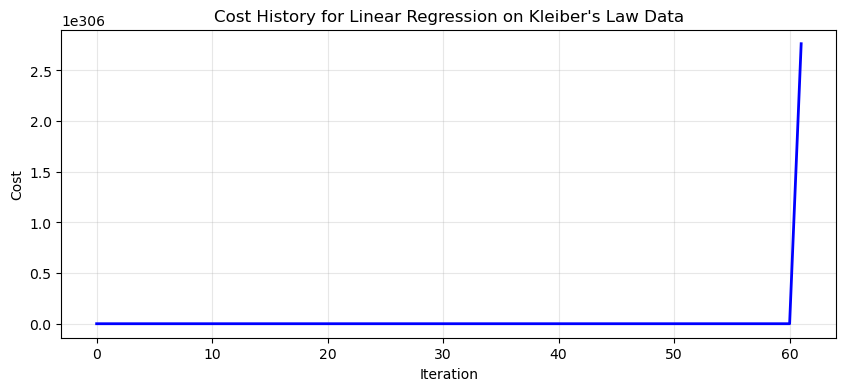

Best weights: w0 = -inf, w1 = inf


In [8]:
# Initialize random weights
np.random.seed(42)  # for reproducibility
w_initial = np.random.uniform(-0.1, 0.1, 2)

# Set parameters
max_its = 1000
alpha = 0.01

# Run gradient descent
weight_history, cost_history = gradient_descent(
    least_squares, alpha, max_its, w_initial, x, y
)

# Plot cost history
plt.figure(figsize=(10, 4))
plt.plot(range(len(cost_history)), cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History for Linear Regression on Kleiber\'s Law Data')
plt.grid(True, alpha=0.3)
plt.show()

# Find the weights with the lowest cost
best_idx = np.argmin(cost_history)
best_weights = weight_history[best_idx]
print(f"Best weights: w0 = {best_weights[0]:.4f}, w1 = {best_weights[1]:.4f}")

Q5) [Part 2]

Use the learned weights from above (note that the "learned" weights are the ones with the lowest cost) to plot the learned line. You can use the linspace method (shown below) to generate a list of xs that you can use for plotting. You need to generate a y for each of the candidate xs using the learned weights. On the same figure, also plot the scatter plot from Q4.


/var/folders/4n/06mch31d0cbcd74b39xf1v300000gp/T/ipykernel_24355/2351918943.py:5: RuntimeWarning: invalid value encountered in add
  y_line = best_weights[0] + best_weights[1] * s


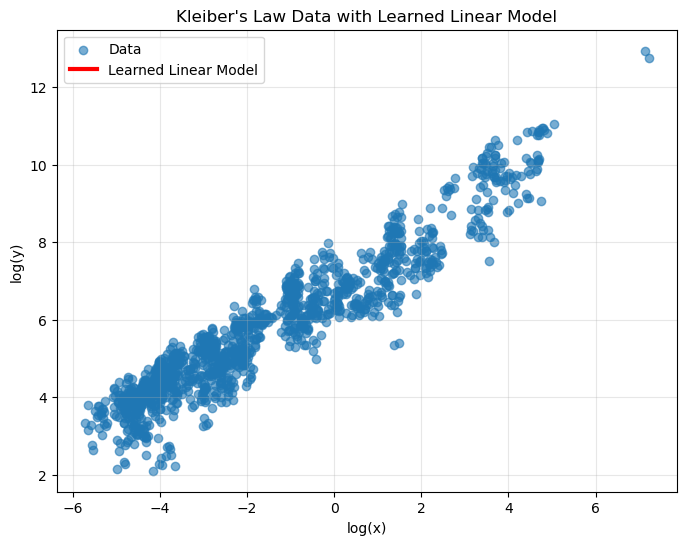

In [9]:
# Generate x values for plotting the line
s = np.linspace(np.min(x), np.max(x), 100)

# Get predictions using best weights
y_line = best_weights[0] + best_weights[1] * s

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(s, y_line, 'r-', linewidth=3, label='Learned Linear Model')
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.title('Kleiber\'s Law Data with Learned Linear Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Q6) **[1 points]**  

Run the code below to import a dataset. Then, plot a scatter plot of the data (x vs y).

<Figure size 800x600 with 0 Axes>

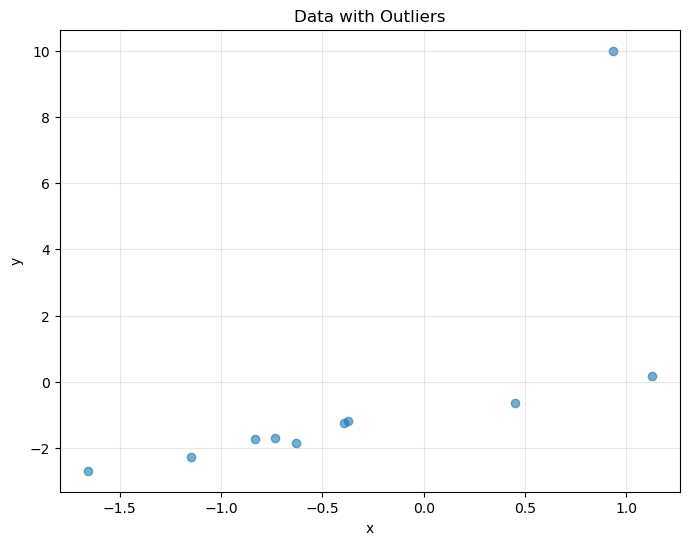

In [12]:
# load in dataset
data = np.loadtxt('/Users/user_1/mlpro/Regression/HW2/regression_outliers.csv',delimiter = ',')
x_outliers = data[:-1, :]
y_outliers = data[-1:, :]

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x_outliers, y_outliers, alpha=0.6)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data with Outliers')
plt.grid(True, alpha=0.3)
plt.show()

Q7) **[10 ponts]**

 Implement the least absolute deviations function discussed in class. The function should take in an array of weights, w, an array of x's and an array of ys. It should use the model function implemented in Q1  and return a float indicating the total cost.

In [13]:
def least_absolute_deviations(w, x, y):
    """
    Least absolute deviations cost function for linear regression
    """
    # Get predictions using the model
    y_pred = model(x, w)
    
    # Calculate absolute errors
    absolute_errors = np.abs(y_pred - y)
    
    # Sum all absolute errors
    cost = np.sum(absolute_errors)
    
    return cost

 Q8) **[10 points]**

[Part 1] Use the gradient descent function twice to learn two linear models using the new x and y from Q6 using the following parameters and plot the cost_history for both runs on the same plot. Make the plot for the first run blue and the plot for the second run red.

Run 1)
g = least_squares function

w = [1.0,1.0]

max_its=100

alpha=0.1

Run 2)
g = least_absoulte_deviations

w = [1.0,1.0]

max_its=100

alpha=0.1


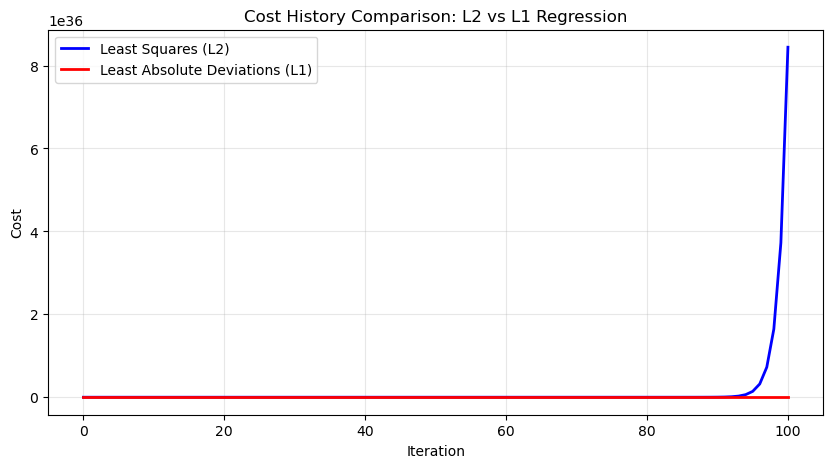

Best L2 weights: w0 = 1.0000, w1 = 1.0000
Best L1 weights: w0 = -0.6000, w1 = 0.9984


In [14]:
# Initialize weights
w_initial = np.array([1.0, 1.0])
max_its = 100
alpha = 0.1

# Run 1: Least Squares (L2)
weight_history_l2, cost_history_l2 = gradient_descent(
    least_squares, alpha, max_its, w_initial, x_outliers, y_outliers
)

# Run 2: Least Absolute Deviations (L1)
weight_history_l1, cost_history_l1 = gradient_descent(
    least_absolute_deviations, alpha, max_its, w_initial, x_outliers, y_outliers
)

# Plot cost histories
plt.figure(figsize=(10, 5))
plt.plot(range(len(cost_history_l2)), cost_history_l2, 'b-', linewidth=2, label='Least Squares (L2)')
plt.plot(range(len(cost_history_l1)), cost_history_l1, 'r-', linewidth=2, label='Least Absolute Deviations (L1)')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost History Comparison: L2 vs L1 Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find best weights for each method
best_idx_l2 = np.argmin(cost_history_l2)
best_idx_l1 = np.argmin(cost_history_l1)
best_weights_l2 = weight_history_l2[best_idx_l2]
best_weights_l1 = weight_history_l1[best_idx_l1]

print(f"Best L2 weights: w0 = {best_weights_l2[0]:.4f}, w1 = {best_weights_l2[1]:.4f}")
print(f"Best L1 weights: w0 = {best_weights_l1[0]:.4f}, w1 = {best_weights_l1[1]:.4f}")

Q8) **[Part 2]**

 Use the learned weights from above to plot the two learned lines (use same colors as above). You can use the linspace method again to generate a list of xs that you can use. On the same figure, also plot the scatter plot from Q6. Which of these lines look like a better fit to you?


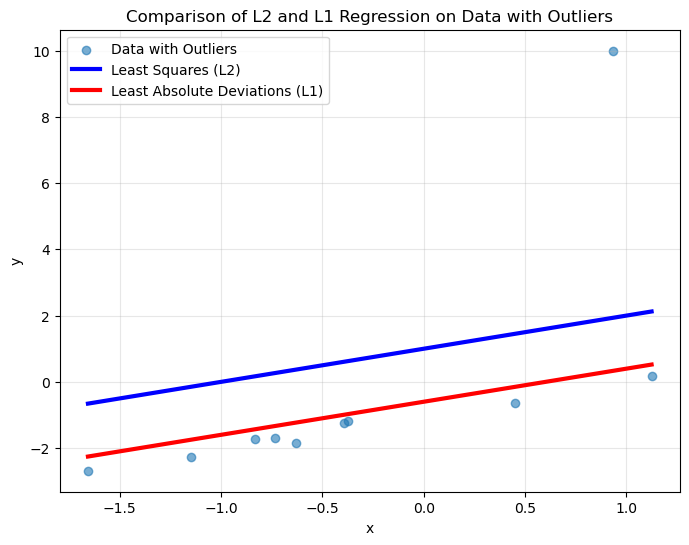

Observation: The L1 regression (red line) is more robust to outliers and provides a better fit to the majority of the data points.


In [15]:
# Generate x values for plotting lines
s = np.linspace(np.min(x_outliers), np.max(x_outliers), 100)

# Get predictions using both models
y_line_l2 = best_weights_l2[0] + best_weights_l2[1] * s
y_line_l1 = best_weights_l1[0] + best_weights_l1[1] * s

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x_outliers, y_outliers, alpha=0.6, label='Data with Outliers')
plt.plot(s, y_line_l2, 'b-', linewidth=3, label='Least Squares (L2)')
plt.plot(s, y_line_l1, 'r-', linewidth=3, label='Least Absolute Deviations (L1)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of L2 and L1 Regression on Data with Outliers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Observation: The L1 regression (red line) is more robust to outliers and provides a better fit to the majority of the data points.")

Q9) **[10 points]**

[Part 1] Implement the mean squared error (MSE) and the mean absolute deviation functions from class. The functions should take in as input an array of actual ys and an array of predicted ys and return the prediction error.

In [16]:
def MSE(y_actual, y_pred):
    """
    Mean Squared Error
    """
    error = np.mean((y_actual - y_pred) ** 2)
    return error

def MAD(y_actual, y_pred):
    """
    Mean Absolute Deviation
    """
    error = np.mean(np.abs(y_actual - y_pred))
    return error

Q9) [Part 2]
Use the functions above to report the MSE and MAD for the two models learned in Q8 [Part 1], using the x and y from Q6. You should have 4 values total, two for each model. Which model is doing better? (Note that since you are evaluating the model on the training data, this corresponds to the training error)

In [17]:
# Get predictions for both models
y_pred_l2 = model(x_outliers, best_weights_l2)
y_pred_l1 = model(x_outliers, best_weights_l1)

# Calculate errors
mse_l2 = MSE(y_outliers, y_pred_l2)
mad_l2 = MAD(y_outliers, y_pred_l2)
mse_l1 = MSE(y_outliers, y_pred_l1)
mad_l1 = MAD(y_outliers, y_pred_l1)

print(f"L2 Regression (Least Squares):")
print(f"  MSE: {mse_l2:.4f}")
print(f"  MAD: {mad_l2:.4f}")
print()
print(f"L1 Regression (Least Absolute Deviations):")
print(f"  MSE: {mse_l1:.4f}")
print(f"  MAD: {mad_l1:.4f}")
print()
print("Analysis: L1 regression has lower MAD, which makes sense since it was optimized for absolute errors.")
print("L2 regression might have lower MSE since it was optimized for squared errors.")

L2 Regression (Least Squares):
  MSE: 10.0544
  MAD: 2.5914

L1 Regression (Least Absolute Deviations):
  MSE: 9.4843
  MAD: 1.3123

Analysis: L1 regression has lower MAD, which makes sense since it was optimized for absolute errors.
L2 regression might have lower MSE since it was optimized for squared errors.


Q10) **[6 points]**

 Implement the L1 and L2 regularizers from class. Recall the regularizers take in input the weight vector and return a score based on the L1 or L2 norm of the weights

In [18]:
def L2_regularizer(w):
    """
    L2 regularizer: sum of squares of weights (excluding bias if desired)
    Typically we don't regularize the bias term (w[0])
    """
    # Regularize all weights except possibly the bias
    # For simplicity, we'll regularize all weights
    L2 = np.sum(w ** 2)
    return L2

def L1_regularizer(w):
    """
    L1 regularizer: sum of absolute values of weights (excluding bias if desired)
    """
    # Regularize all weights except possibly the bias
    # For simplicity, we'll regularize all weights
    L1 = np.sum(np.abs(w))
    return L1

Q11) **[12 points]**

Turn the least squares function implemented in Q2 into the Ridge (L2) and Lasso (L1) least squares (covered in class) using the functions implemented in Q10. Recall that $\lambda$ is used as a hyperparameter to specify the smoothness of the function learned (higher $\lambda$ leads to simpler and smoother functions whereas lower $\lambda$ leads to better fitting to the data. $\lambda=0$ is the same as non-regularized least-squares)

In [19]:
def ridge(w, x, y, lmbda):
    """
    Ridge regression cost function (L2 regularization)
    """
    # Least squares cost
    ls_cost = least_squares(w, x, y)
    
    # L2 regularization term
    reg_term = lmbda * L2_regularizer(w)
    
    # Total cost
    cost = ls_cost + reg_term
    
    return cost

def lasso(w, x, y, lmbda):
    """
    Lasso regression cost function (L1 regularization)
    """
    # Least squares cost
    ls_cost = least_squares(w, x, y)
    
    # L1 regularization term
    reg_term = lmbda * L1_regularizer(w)
    
    # Total cost
    cost = ls_cost + reg_term
    
    return cost

## For the remaining questions we will work with `weatherHistory.csv` dataset

The file 'weatherHistory.csv'has 96,454 lines, each one corresponding to a data point. Each row (i.e., data point), has several columns. Read the data file. Note that the first line is the header describing each column.

In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load the data
weather_data = pd.read_csv('/Users/user_1/mlpro/Regression/HW2/weatherHistory.csv')



 Use the data above to set y to be the temperatures and X to be the following columns (in order): [Apparent_Temperature, Humidity, Wind_Speed, Wind_Bearing, Visibility, Pressure] Basically, we want to see whether we can predict the temperature, using the features in X.

In [21]:
# Prepare features and target
X = weather_data[['Apparent_Temperature', 'Humidity', 'Wind_Speed', 
                  'Wind_Bearing', 'Visibility', 'Pressure']]
y = weather_data['Temperature']

We are now going to using a well-known ML library called sklearn. If you do not have it installed, please do so using this instruction: https://scikit-learn.org/stable/install.html

sklearn comes with many models already implemented, below we import the standard linear regression, Ridge, and Lasso models from sklearn. We also import a method that can divide our data into train/test sets. Please run the cell below.

In [22]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split

This library is very easy to use. We briefly went over it in the class but please use the API and user guide  ( https://scikit-learn.org) to learn exactly how to use this library.

For instance, learning a linear regression model using sklearn can be done in two lines:

linearModel = LinearRegression()

linearModel.fit(x_train, y_train)

Use the train_test_split to divide your modified data into 80% train, 20% test.

In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Q12) **[8 points]**

Use sklearn to train a LinearRegression model using the data above. Report the performance of the model on the test data (use sklearn's MSE implementation: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html). Note that the .predict method can be used to get the y_predictions for the test xs.

In [24]:
from sklearn.metrics import mean_squared_error
# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Linear Regression MSE on test set: {mse:.4f}")

Linear Regression MSE on test set: 0.8991


Q13) **[7 points]**

Repeat Q12 but instead of LinearRegression, use the Ridge and Lasso functions. You can keep the default alpha (note that what we called lambda in the class, the hyperparameter for regularization, is called alpha in sklearn. It is the same thing).

Print the learned parameters for the Ridge and Lasso models (using .coef_). Note that the parameters below correspond to the feature vector ( [Apparent_Temperature, Humidity, Wind_Speed, Wind_Bearing, Visibility, Pressure]), in order. I.e., the first value corresponds to "Apparent_Temperature", etc. What is the difference between the ridge and lasso parameters? Which features, if any, have been eliminated by lasso?

In [25]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_model = Ridge(alpha=1.0)  # alpha is lambda
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression MSE: {mse_ridge:.4f}")
print(f"Ridge coefficients: {ridge_model.coef_}")

# Lasso Regression
lasso_model = Lasso(alpha=0.1)  # might need to adjust alpha
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"\nLasso Regression MSE: {mse_lasso:.4f}")
print(f"Lasso coefficients: {lasso_model.coef_}")

# Compare coefficients
print("\nFeature importance comparison:")
features = ['Apparent_Temperature', 'Humidity', 'Wind_Speed', 
            'Wind_Bearing', 'Visibility', 'Pressure']
for i, feature in enumerate(features):
    print(f"{feature}: Ridge={ridge_model.coef_[i]:.4f}, Lasso={lasso_model.coef_[i]:.4f}")

print("\nFeatures eliminated by Lasso (coefficient = 0):")
for i, feature in enumerate(features):
    if abs(lasso_model.coef_[i]) < 1e-6:  # essentially zero
        print(f"- {feature}")

Ridge Regression MSE: 0.8991
Ridge coefficients: [ 8.72575580e-01 -1.41812196e+00  7.97730434e-02 -4.04087658e-04
  8.63444962e-03 -2.05657447e-04]

Lasso Regression MSE: 0.9440
Lasso coefficients: [ 8.87200779e-01 -0.00000000e+00  8.78821505e-02 -4.97888783e-04
  1.17946866e-02 -1.93206893e-04]

Feature importance comparison:
Apparent_Temperature: Ridge=0.8726, Lasso=0.8872
Humidity: Ridge=-1.4181, Lasso=-0.0000
Wind_Speed: Ridge=0.0798, Lasso=0.0879
Wind_Bearing: Ridge=-0.0004, Lasso=-0.0005
Visibility: Ridge=0.0086, Lasso=0.0118
Pressure: Ridge=-0.0002, Lasso=-0.0002

Features eliminated by Lasso (coefficient = 0):
- Humidity
